In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv("data/customer_churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (2000, 12)


In [3]:
df.head()

,Customer_ID,Age,Gender,Tenure_Months,Contract,Internet_Service,Online_Security,Tech_Support,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,CUST0001,56,Male,38,One Year,DSL,Yes,Yes,Debit Card,118.16,1326.97,No
1,CUST0002,69,Female,53,Month-to-Month,Fiber Optic,No,Yes,UPI,117.88,367.62,Yes
2,CUST0003,46,Female,61,One Year,DSL,Yes,Yes,Credit Card,87.32,7919.75,No
3,CUST0004,32,Female,36,One Year,DSL,No,Yes,Debit Card,135.80,3909.79,No
4,CUST0005,60,Female,40,Month-to-Month,Fiber Optic,Yes,No,Credit Card,96.45,4619.40,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       2000 non-null   str    
 1   Age               2000 non-null   int64  
 2   Gender            2000 non-null   str    
 3   Tenure_Months     2000 non-null   int64  
 4   Contract          2000 non-null   str    
 5   Internet_Service  2000 non-null   str    
 6   Online_Security   2000 non-null   str    
 7   Tech_Support      2000 non-null   str    
 8   Payment_Method    2000 non-null   str    
 9   Monthly_Charges   2000 non-null   float64
 10  Total_Charges     2000 non-null   float64
 11  Churn             2000 non-null   str    
dtypes: float64(2), int64(2), str(8)
memory usage: 187.6 KB


In [5]:
df.isnull().sum()

Customer_ID         0
Age                 0
Gender              0
Tenure_Months       0
Contract            0
Internet_Service    0
Online_Security     0
Tech_Support        0
Payment_Method      0
Monthly_Charges     0
Total_Charges       0
Churn               0
dtype: int64

In [6]:
df["Churn"].value_counts()

Churn
No     1032
Yes     968
Name: count, dtype: int64

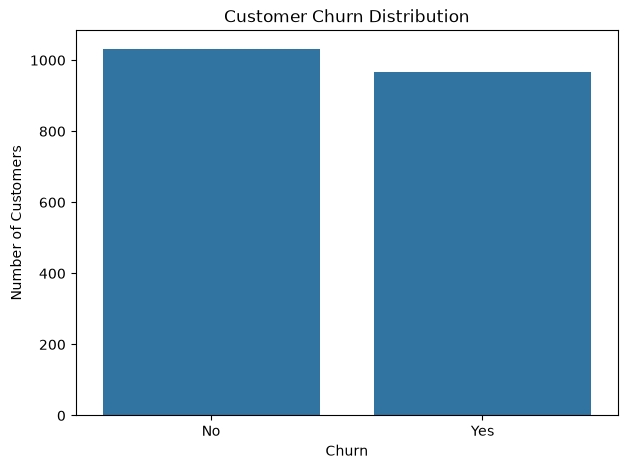

In [7]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [8]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print("Churn Percentage:")
print(churn_percentage.round(2))

Churn Percentage:
Churn
No     51.6
Yes    48.4
Name: proportion, dtype: float64


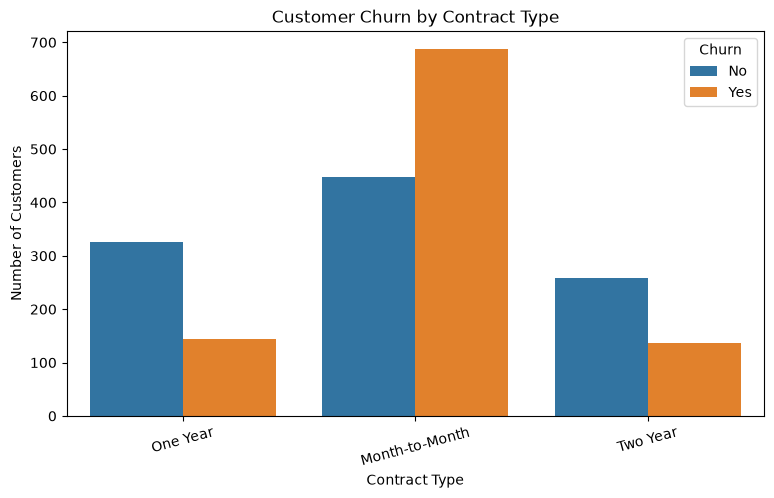

In [9]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

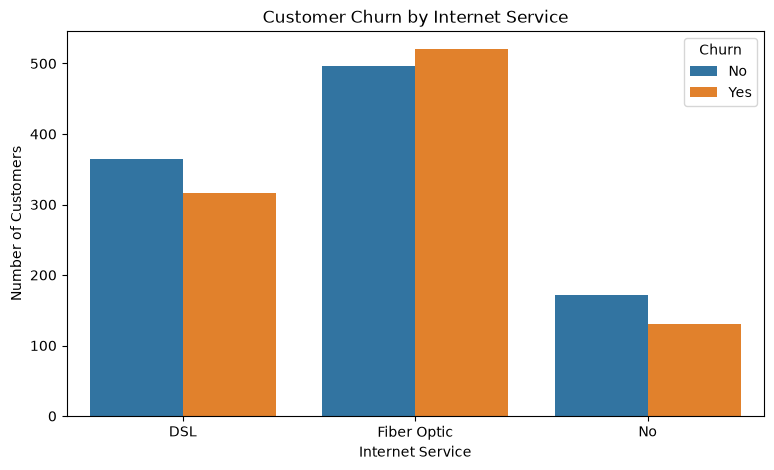

In [10]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df, x="Internet_Service", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

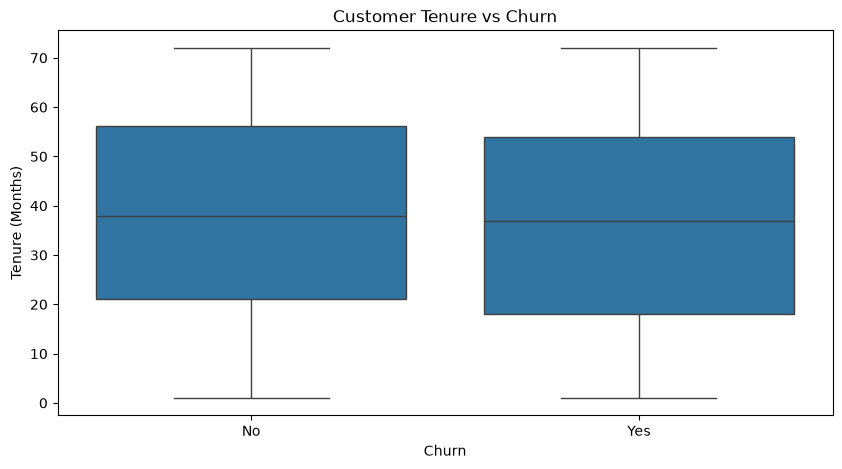

In [11]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="Churn", y="Tenure_Months")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

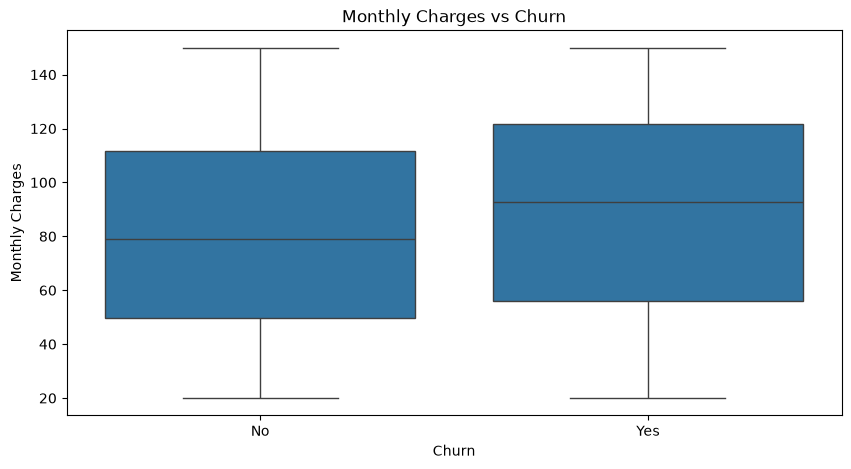

In [12]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="Churn", y="Monthly_Charges")

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

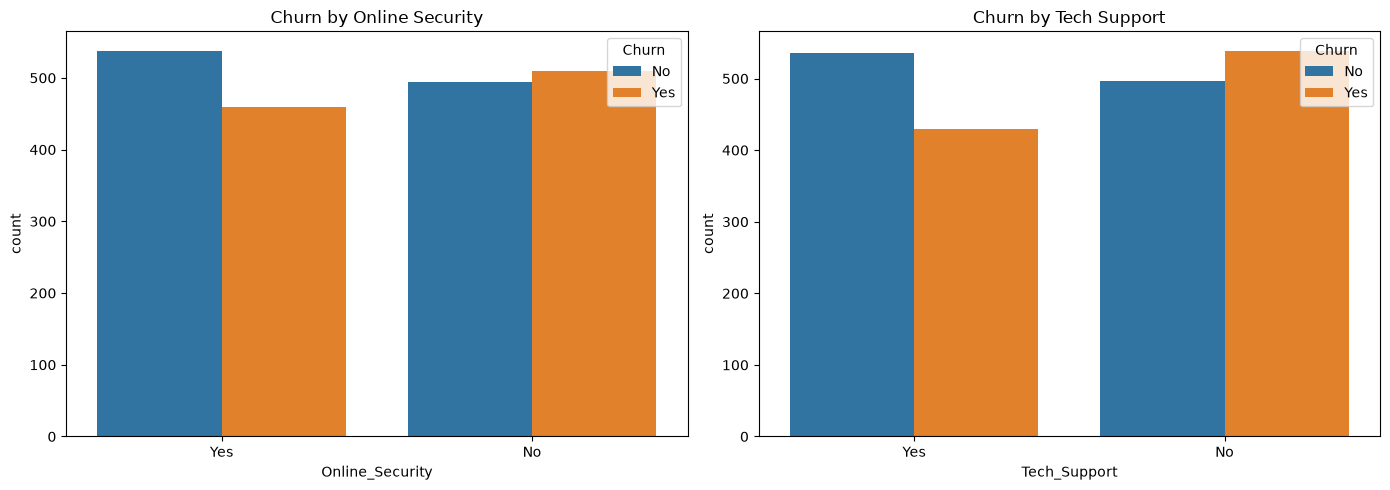

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Online_Security", hue="Churn", ax=axes[0])
axes[0].set_title("Churn by Online Security")

sns.countplot(data=df, x="Tech_Support", hue="Churn", ax=axes[1])
axes[1].set_title("Churn by Tech Support")

plt.tight_layout()
plt.show()

In [14]:
total_customers = df["Customer_ID"].nunique()
churned_customers = (df["Churn"] == "Yes").sum()

churn_rate = (churned_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", round(churn_rate, 2), "%")

Total Customers: 2000
Churned Customers: 968
Churn Rate: 48.4 %


In [15]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("Churn Rate by Contract:")
print(contract_churn.round(2))

Churn Rate by Contract:
Contract
Month-to-Month    60.58
Two Year          34.43
One Year          30.79
Name: Churn, dtype: float64


In [16]:
internet_churn = (
    df.groupby("Internet_Service")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("Churn Rate by Internet Service:")
print(internet_churn.round(2))

Churn Rate by Internet Service:
Internet_Service
Fiber Optic    51.18
DSL            46.48
No             43.38
Name: Churn, dtype: float64


In [17]:
df["Tenure_Group"] = pd.cut(
    df["Tenure_Months"],
    bins=[0, 12, 36, 100],
    labels=["New", "Medium", "Long-term"]
)

tenure_churn = (
    df.groupby("Tenure_Group", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print("Churn Rate by Tenure Group:")
print(tenure_churn.round(2))

Churn Rate by Tenure Group:
Tenure_Group
New          57.81
Medium       44.66
Long-term    48.07
Name: Churn, dtype: float64


In [18]:
support_churn = (
    df.groupby("Tech_Support")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print("Churn Rate by Tech Support:")
print(support_churn.round(2))

Churn Rate by Tech Support:
Tech_Support
No     52.08
Yes    44.46
Name: Churn, dtype: float64


In [19]:
security_churn = (
    df.groupby("Online_Security")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print("Churn Rate by Online Security:")
print(security_churn.round(2))

Churn Rate by Online Security:
Online_Security
No     50.75
Yes    46.04
Name: Churn, dtype: float64


In [20]:
avg_charges = df.groupby("Churn")["Monthly_Charges"].mean()

print("Average Monthly Charges:")
print(avg_charges.round(2))

Average Monthly Charges:
Churn
No     81.55
Yes    88.64
Name: Monthly_Charges, dtype: float64


In [21]:
summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Overall Churn Rate",
        "Average Monthly Charges - Stayed",
        "Average Monthly Charges - Churned"
    ],
    "Value": [
        total_customers,
        churned_customers,
        round(churn_rate, 2),
        round(avg_charges.get("No", 0), 2),
        round(avg_charges.get("Yes", 0), 2)
    ]
})

summary

,Metric,Value
0,Total Customers,2000.00
1,Churned Customers,968.00
2,Overall Churn Rate,48.40
3,Average Monthly Charges - Stayed,81.55
4,Average Monthly Charges - Churned,88.64


In [22]:
ml_df = df.copy()

print("ML dataset shape:", ml_df.shape)

ML dataset shape: (2000, 13)


In [23]:
ml_df = ml_df.drop(columns=["Customer_ID"])

print(ml_df.head())

   Age  Gender  Tenure_Months        Contract Internet_Service  \
0   56    Male             38        One Year              DSL   
1   69  Female             53  Month-to-Month      Fiber Optic   
2   46  Female             61        One Year              DSL   
3   32  Female             36        One Year              DSL   
4   60  Female             40  Month-to-Month      Fiber Optic   

  Online_Security Tech_Support Payment_Method  Monthly_Charges  Total_Charges  \
0             Yes          Yes     Debit Card           118.16        1326.97   
1              No          Yes            UPI           117.88         367.62   
2             Yes          Yes    Credit Card            87.32        7919.75   
3              No          Yes     Debit Card           135.80        3909.79   
4             Yes           No    Credit Card            96.45        4619.40   

  Churn Tenure_Group  
0    No    Long-term  
1   Yes    Long-term  
2    No    Long-term  
3    No       Medium  
4

In [24]:
ml_df["Churn"] = ml_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(ml_df["Churn"].value_counts())

Churn
0    1032
1     968
Name: count, dtype: int64


In [25]:
X = ml_df.drop(columns=["Churn"])
y = ml_df["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (2000, 11)
Target: (2000,)


In [26]:
categorical_columns = X.select_dtypes(include=["object", "category"]).columns
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:")
print(list(categorical_columns))

print("\nNumerical columns:")
print(list(numerical_columns))

Categorical columns:
['Gender', 'Contract', 'Internet_Service', 'Online_Security', 'Tech_Support', 'Payment_Method', 'Tenure_Group']

Numerical columns:
['Age', 'Tenure_Months', 'Monthly_Charges', 'Total_Charges']


C:\Users\srinivas\AppData\Local\Temp\ipykernel_14116\4251424083.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object", "category"]).columns


In [27]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Encoded feature shape:", X_encoded.shape)

Encoded feature shape: (2000, 16)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1600
Testing samples: 400


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [31]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully!
First 10 predictions: [0 1 1 1 1 1 0 0 0 1]


In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 67.25 %


In [33]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Churned"]
))

              precision    recall  f1-score   support

      Stayed       0.68      0.68      0.68       206
     Churned       0.66      0.66      0.66       194

    accuracy                           0.67       400
   macro avg       0.67      0.67      0.67       400
weighted avg       0.67      0.67      0.67       400



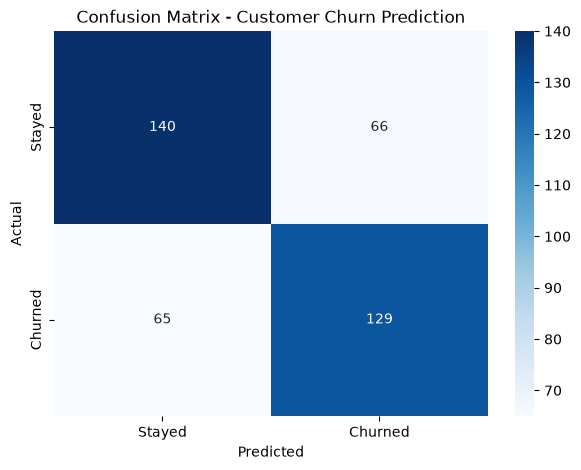

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Confusion Matrix - Customer Churn Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
from sklearn.metrics import roc_auc_score

y_probability = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", round(roc_auc, 3))

ROC-AUC Score: 0.706


In [36]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute_Importance"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Importance
5,Contract_One Year,-0.518931,0.518931
6,Contract_Two Year,-0.425123,0.425123
10,Tech_Support_Yes,-0.215508,0.215508
14,Tenure_Group_Medium,-0.211595,0.211595
1,Tenure_Months,-0.194586,0.194586
2,Monthly_Charges,0.184391,0.184391
11,Payment_Method_Credit Card,-0.119883,0.119883
12,Payment_Method_Debit Card,-0.094764,0.094764
9,Online_Security_Yes,-0.078122,0.078122
7,Internet_Service_Fiber Optic,0.077960,0.077960


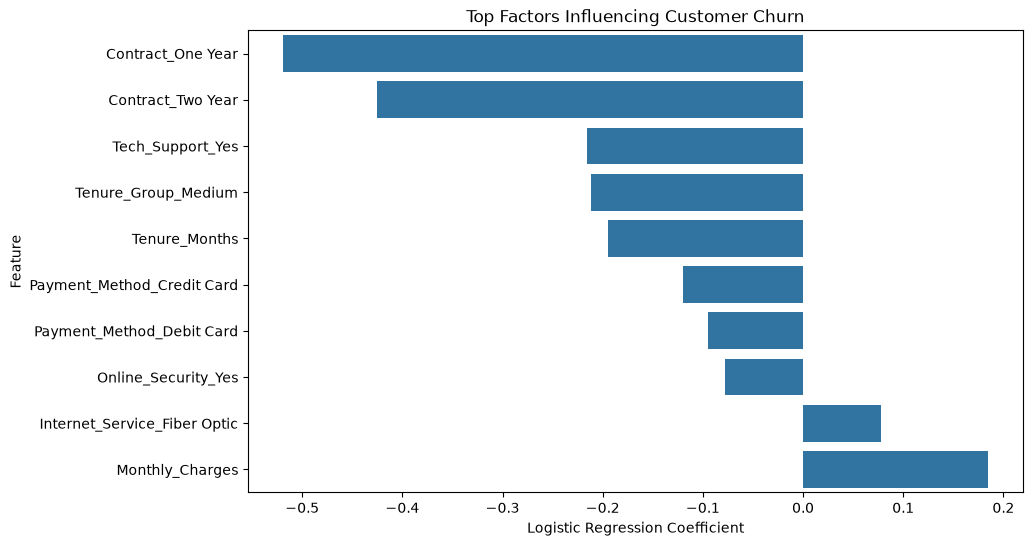

In [37]:
top_features = feature_importance.head(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Factors Influencing Customer Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.show()

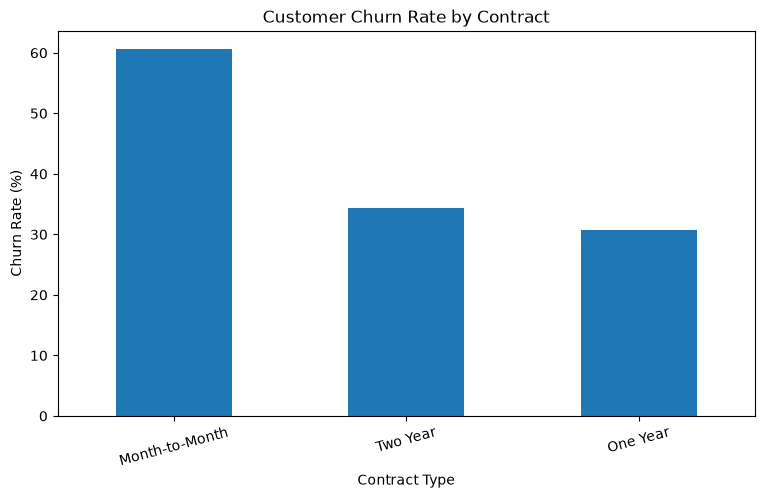

In [38]:
contract_rates = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

contract_rates.plot(kind="bar")

plt.title("Customer Churn Rate by Contract")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.show()

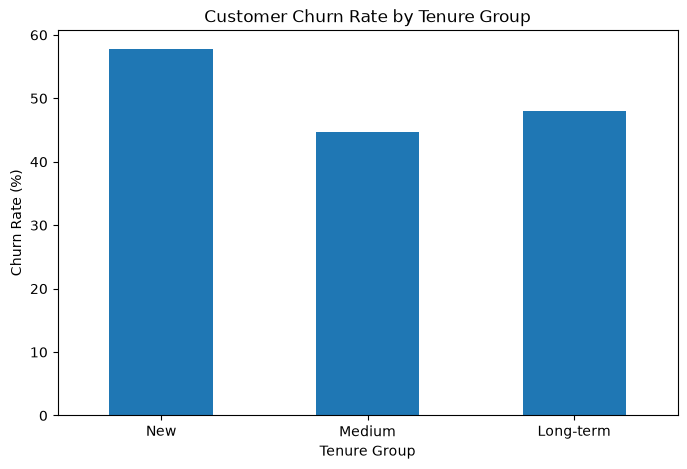

In [39]:
tenure_rates = (
    df.groupby("Tenure_Group", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))

tenure_rates.plot(kind="bar")

plt.title("Customer Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

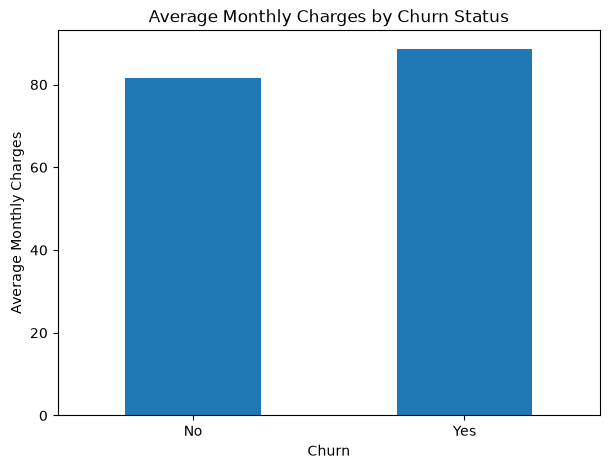

In [40]:
charge_rates = df.groupby("Churn")["Monthly_Charges"].mean()

plt.figure(figsize=(7, 5))

charge_rates.plot(kind="bar")

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.show()

In [41]:
feature_importance.to_csv(
    "data/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!
